# Análisis de Grandes Volúmenes de Datos | TC4034.10


## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey
## Actividad 5 | Visualización de Resultados

---

### Team 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo - A01797078

---

## Objetivo

Mostrar los resultados obtenidos a partir de la aplicación de un proceso de entrenamiento
de modelos de aprendizaje máquina en grandes volúmenes de datos, mediante el uso de
herramientas de visualización como gráficas de dispersión, de tendencia central, mapas de
calor y curvas ROC.

---

---

**Continuidad con actividades previas:**

| Actividad | Resultado relevante |
|---|---|
| Act 3 — Módulo 4 | Se definieron particiones para los viajes de Manhattan usando distancia del viaje y franja horaria, generando 6 estratos representativos. |
| Act 4 — Módulo 5 | Se evaluaron modelos de aprendizaje y métricas de calidad. Para esta actividad se retoma **XGBoost** como modelo principal para la predicción de `fare_amount`. |

En esta actividad se replica el flujo de preparación de datos utilizado en actividades anteriores y se construye una muestra estratificada proporcional de aproximadamente **1% de los viajes de Manhattan**. Esta muestra conserva la estructura de los 6 estratos definidos previamente y permite realizar validación cruzada, entrenamiento, evaluación y visualización de resultados.

Aunque una muestra automática de mayor tamaño podía acercarse a más de **40 millones de registros**, trabajar con ese volumen implicaba un costo computacional muy alto para la experimentación con k-fold. Por esta razón, se decidió usar una muestra más manejable de **1,005,818 registros**, manteniendo representatividad por estrato y un tiempo de ejecución razonable.

| Elemento | Decisión tomada |
|---|---|
| Población de referencia | Viajes de taxi con origen en Manhattan |
| Estratos | Distancia del viaje y franja horaria |
| Tamaño de muestra | Aproximadamente 1% de Manhattan |
| Modelo principal | XGBoost |
| Variable objetivo | `fare_amount` |
| Enfoque de evaluación | Validación cruzada k-fold + conjunto de test independiente |

Esta decisión permite balancear dos aspectos importantes: por un lado, conservar una muestra suficientemente grande y representativa para un problema de Big Data; por otro, mantener la experimentación viable considerando que el entrenamiento se repite varias veces durante la validación cruzada.


## Configuración inicial

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pyspark.sql import SparkSession
from pyspark import StorageLevel
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.window import Window

# Pipeline ML
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import (VectorAssembler, StringIndexer, OneHotEncoder,
                                 StandardScaler)
from pyspark.ml.stat import Correlation
from xgboost.spark import SparkXGBRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t as t_dist, norm as sp_norm, probplot
from scipy.spatial import ConvexHull, Delaunay

import os, requests, warnings
import logging

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [3]:
spark = (SparkSession.builder
         .appName('BigData_Actividad5_Equipo8')
        #  .config('spark.driver.memory',           '12g')
        #  .config('spark.driver.maxResultSize',    '4g')
        #  .config('spark.memory.offHeap.enabled',  'true')
        #  .config('spark.memory.offHeap.size',     '2g')
        #  .config('spark.sql.shuffle.partitions',  '100')
         .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')
logging.getLogger('XGBoost-PySpark').setLevel(logging.ERROR)

print('Spark listo — versión:', spark.version)

Spark listo — versión: 4.0.2


In [4]:
# ── Constantes globales ────────────────────────────────────────────────────
f_path   = '/content/drive/MyDrive/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/raw/taxi/yellow/clean'
# f_path   = '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/particionado/'
SEED     = 42
K        = 5          # número de pliegues (justificado en Sección 1)
N_TARGET = 120_000    # valor de referencia; la muestra final se construye con sample_fraction = 0.01

BEST_PARAMS_XGBOOST = {
  "n_estimators": 150,
  "max_depth": 6,
  "learning_rate": 0.05,
  "subsample": 0.9,
  "colsample_bytree": 0.9,
}

TARGET = 'fare_amount'

NUMERIC_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'passenger_count',
    'is_rush_hour', 'is_weekend', 'pickup_hour',
    'Airport_fee', 'congestion_surcharge', 'pickup_month_c',
]
CATEGORICAL_FEATURES = ['time_of_day', 'distance_cat']

FARE_THRESHOLD = 15.0   # umbral para binarización en curva ROC (USD)

print(f"K         = {K}")
print(f"N_TARGET  = {N_TARGET:,}")
print(f"TARGET    = {TARGET}")
print(f"BEST PARAMS XGBOOST: {BEST_PARAMS_XGBOOST}")

K         = 5
N_TARGET  = 120,000
TARGET    = fare_amount
BEST PARAMS XGBOOST: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9}


## Sección 0. Preparación de datos y construcción de la muestra M

Para esta actividad se replica el pipeline de preparación de datos usado en actividades anteriores: limpieza, generación de variables, integración con la tabla de zonas TLC y filtrado de viajes con origen en Manhattan.

A partir de la población filtrada de Manhattan, se construyó una muestra M mediante muestreo estratificado proporcional usando `sampleBy`. Los estratos se definieron con dos variables de caracterización: distancia del viaje (`distance_cat`) y franja horaria (`hour_range`), lo que genera 6 combinaciones.

Aunque una muestra automática de mayor tamaño podía ser más representativa desde el punto de vista estadístico, su uso elevaba demasiado el costo computacional de la validación cruzada. Por ello, **se utilizó una fracción de muestreo de 1% por estrato, obteniendo una muestra de 1,005,818 registros.** Esta decisión permite mantener representatividad por partición y, al mismo tiempo, ejecutar la validación cruzada y las visualizaciones en un tiempo razonable.


In [6]:
# 0.1 Ingesta
# df = spark.read.option('pathGlobFilter', '*.parquet').parquet(f_path)
df = spark.read.parquet(f"{f_path}")

raw_count = df.count()
print(f"Filas   : {raw_count:,}")
print(f"Columnas: {len(df.columns)}")

Filas   : 139,279,754
Columnas: 24


In [7]:
# 0.2 Limpieza — mismos criterios que en las actividades anteriores
df_clean = (df
    .dropna(subset=['fare_amount', 'trip_distance', 'passenger_count',
                    'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .filter(F.col('passenger_count').between(1, 8))
    .withColumn('trip_duration_minutes',
               (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60)
    .filter(F.col('trip_duration_minutes').between(1, 300))
    .fillna(0, subset=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                       'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']))

clean_count = df_clean.count()
print(f"Filas tras limpieza: {clean_count:,}  ({100*clean_count/raw_count:.1f}% del original)")

Filas tras limpieza: 113,426,162  (81.4% del original)


In [8]:
# 0.3 Feature Engineering (idéntico a Actividades 3 y 4)
df_clean.createOrReplaceTempView('taxi_clean')

df_fe = spark.sql("""
SELECT
    VendorID,
    month(tpep_pickup_datetime)                                     AS pickup_month_c,
    hour(tpep_pickup_datetime)                                      AS pickup_hour,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  0 AND  5 THEN 'Noche'
        WHEN hour(tpep_pickup_datetime) BETWEEN  6 AND 11 THEN 'Manana'
        WHEN hour(tpep_pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
        ELSE 'Tarde-Noche'
    END                                                             AS time_of_day,
    CASE WHEN dayofweek(tpep_pickup_datetime) IN (1,7) THEN 1 ELSE 0 END     AS is_weekend,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  7 AND  9
          OR hour(tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 1 ELSE 0
    END                                                             AS is_rush_hour,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                             AS distance_cat,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN 0 AND 11 THEN 'primera_mitad_dia'
        ELSE 'segunda_mitad_dia'
    END                                                             AS hour_range,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    passenger_count,
    congestion_surcharge,
    Airport_fee,
    tip_amount,
    total_amount,
    PULocationID
FROM taxi_clean
""")
print("Feature engineering completado.")

Feature engineering completado.


In [9]:
# 0.4 Integración geográfica de zonas (Manhattan) y construcción de estratos
zones_url  = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
zones_path = f_path + 'taxi_zone_lookup.csv'

if not os.path.exists(zones_path):
    resp = requests.get(zones_url)
    resp.raise_for_status()
    with open(zones_path, 'wb') as fz:
        fz.write(resp.content)

zones = spark.read.csv(zones_path, header=True, inferSchema=True)
zones_pu = zones.select(
    F.col('LocationID').alias('PULocationID'),
    F.col('Borough').alias('pickup_borough'))

df_stratified = (df_fe
    .join(zones_pu, on='PULocationID', how='left')
    .filter(F.col('pickup_borough') == 'Manhattan')
    .withColumn('strata_key',
                F.concat_ws('_', F.col('distance_cat'), F.col('hour_range'))))

strata = [r['strata_key'] for r in
          df_stratified.select('strata_key').distinct().orderBy('strata_key').collect()]
print(f"Estratos identificados ({len(strata)}):")
for s in strata:
    print(f"  {s}")

Estratos identificados (6):
  corto_primera_mitad_dia
  corto_segunda_mitad_dia
  largo_primera_mitad_dia
  largo_segunda_mitad_dia
  medio_primera_mitad_dia
  medio_segunda_mitad_dia


In [10]:
df_stratified.printSchema()

root
 |-- PULocationID: short (nullable = true)
 |-- VendorID: byte (nullable = true)
 |-- pickup_month_c: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- time_of_day: string (nullable = false)
 |-- is_weekend: integer (nullable = false)
 |-- is_rush_hour: integer (nullable = false)
 |-- distance_cat: string (nullable = false)
 |-- hour_range: string (nullable = false)
 |-- trip_distance: float (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- congestion_surcharge: float (nullable = false)
 |-- Airport_fee: float (nullable = false)
 |-- tip_amount: float (nullable = false)
 |-- total_amount: float (nullable = true)
 |-- pickup_borough: string (nullable = true)
 |-- strata_key: string (nullable = false)



In [11]:
count_stratified = df_stratified.count()
print(f"{count_stratified:,}")

100,433,346


In [12]:
#@title Selección de muestra proporcional por partición
sample_fraction = 0.01 # 1% de cada partición

sample = (
  # df_stratified contiene nuestras particiones base (descritas anteriormente)
  df_stratified
  # Usamos `sampleBy` para obtener la muestra estratificada por parte de PySpark
    .sampleBy(
        "strata_key",
        fractions={
            "corto_primera_mitad_dia": sample_fraction,
            "medio_primera_mitad_dia": sample_fraction,
            "largo_primera_mitad_dia": sample_fraction,
            "corto_segunda_mitad_dia": sample_fraction,
            "medio_segunda_mitad_dia": sample_fraction,
            "largo_segunda_mitad_dia": sample_fraction,
        },
        seed=42
    )
)

In [13]:
sample.limit(10).toPandas()

,PULocationID,VendorID,pickup_month_c,pickup_hour,time_of_day,is_weekend,is_rush_hour,distance_cat,hour_range,trip_distance,trip_duration_minutes,fare_amount,passenger_count,congestion_surcharge,Airport_fee,tip_amount,total_amount,pickup_borough,strata_key
0,114,2,5,0,Noche,0,0,medio,primera_mitad_dia,6.160000,24.716667,31.000000,1,2.5,0.0,7.200000,43.200001,Manhattan,medio_primera_mitad_dia
1,233,2,5,0,Noche,0,0,corto,primera_mitad_dia,0.630000,5.433333,6.500000,1,2.5,0.0,2.300000,13.800000,Manhattan,corto_primera_mitad_dia
2,249,2,5,0,Noche,0,0,corto,primera_mitad_dia,1.040000,5.000000,7.900000,1,2.5,0.0,3.220000,16.120001,Manhattan,corto_primera_mitad_dia
3,148,1,5,1,Noche,0,0,medio,primera_mitad_dia,2.200000,10.050000,11.400000,2,2.5,0.0,3.300000,19.700001,Manhattan,medio_primera_mitad_dia
4,263,1,5,2,Noche,0,0,corto,primera_mitad_dia,1.500000,4.516667,8.600000,1,2.5,0.0,0.000000,13.600000,Manhattan,corto_primera_mitad_dia
5,114,2,5,2,Noche,0,0,medio,primera_mitad_dia,4.930000,17.800000,23.299999,1,2.5,0.0,0.000000,28.299999,Manhattan,medio_primera_mitad_dia
6,114,2,5,2,Noche,0,0,medio,primera_mitad_dia,3.610000,13.000000,18.400000,1,2.5,0.0,4.680000,28.080000,Manhattan,medio_primera_mitad_dia
7,230,2,5,3,Noche,0,0,corto,primera_mitad_dia,1.390000,6.883333,9.300000,2,2.5,0.0,3.580000,17.879999,Manhattan,corto_primera_mitad_dia
8,75,2,5,3,Noche,0,0,medio,primera_mitad_dia,2.330000,7.550000,12.100000,1,0.0,0.0,0.000000,14.600000,Manhattan,medio_primera_mitad_dia
9,186,2,5,4,Noche,0,0,largo,primera_mitad_dia,17.950001,31.700000,70.000000,1,2.5,0.0,16.110001,96.660004,Manhattan,largo_primera_mitad_dia


In [14]:
sample_count = sample.count()
print(f'sample_count: {sample_count:,}')

sample_count: 1,005,818


In [15]:
train_df, test_df = sample.randomSplit([0.8, 0.2])

In [16]:
def get_partition_distribution(df, dataset_name):
    total_rows = df.count()

    return (
        df
        .groupBy("strata_key")
        .count()
        .withColumn(
            "probability",
            F.round(
                (F.col("count") / F.lit(total_rows)) * 100,
                2
            )
        )
        .withColumn(
            "dataset",
            F.lit(dataset_name)
        )
        .select(
            "dataset",
            "strata_key",
            "count",
            "probability"
        )
        .orderBy("strata_key")
    )

In [17]:
original_distribution = get_partition_distribution(sample, "Original")
train_distribution = get_partition_distribution(train_df, "Train")
test_distribution = get_partition_distribution(test_df, "Test")

In [18]:
#@title Comparación de distribución en conjuntos de entrenamiento y prueba
comparison = (
    original_distribution
    .unionByName(train_distribution)
    .unionByName(test_distribution)
)

comparison_pivot = (
    comparison
    .groupBy("strata_key")
    .pivot("dataset")
    .agg(F.first("probability"))
    .orderBy("strata_key")
)

In [19]:
# @title Visualización de Distribución de Particiones

pivot_pd = comparison_pivot.toPandas()
pivot_pd

,strata_key,Original,Test,Train
0,corto_primera_mitad_dia,17.88,17.92,17.87
1,corto_segunda_mitad_dia,45.41,45.33,45.42
2,largo_primera_mitad_dia,1.01,1.05,1.00
3,largo_segunda_mitad_dia,1.62,1.64,1.62
4,medio_primera_mitad_dia,9.97,9.99,9.96
5,medio_segunda_mitad_dia,24.11,24.07,24.12


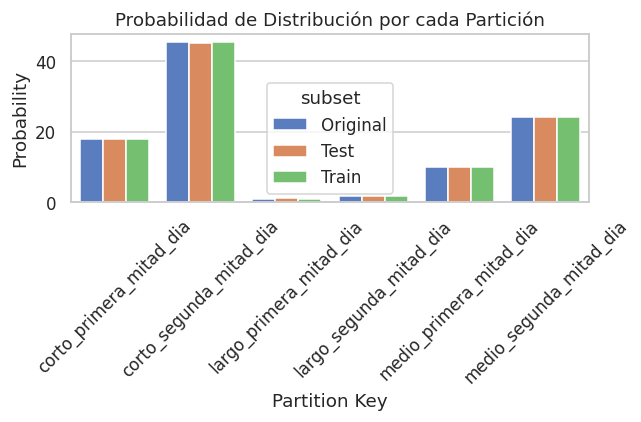

In [20]:
# Ajustamos nuestra tabla pivote para que sea sencillo de
# visualizar mediante un gráfico de barras
df_long = pivot_pd.melt(
    id_vars=['strata_key'],
    var_name='subset',
    value_name='probability'
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_long,
    x='strata_key',
    y='probability',
    hue='subset',
    palette='muted'
)

plt.title('Probabilidad de Distribución por cada Partición')
plt.xlabel('Partition Key')
plt.ylabel('Probability')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Sección 1. Proceso de validación cruzada

Para esta actividad se utilizó un proceso de validación cruzada tipo **k-fold** con `k = 5`, con el objetivo de medir la variabilidad del desempeño del modelo y revisar qué tan estable es al entrenarse con diferentes particiones de los datos.

La validación cruzada permite dividir el conjunto de entrenamiento en varios subconjuntos o folds. En cada iteración, el modelo se entrena con una parte de los folds y se valida con el fold restante. De esta forma, no se evalúa el modelo con una sola partición fija, sino con diferentes combinaciones de entrenamiento y validación, lo que ayuda a tener una estimación más confiable de su desempeño.

Para seleccionar el valor de `k`, se consideró el tamaño de la muestra, la representatividad de los folds y el costo computacional. Aunque una muestra automática de mayor tamaño podía acercarse a más de **40 millones de registros**, utilizar ese volumen completo hacía que el entrenamiento fuera demasiado costoso para los recursos disponibles. Por esta razón, se decidió trabajar con una muestra estratificada proporcional de aproximadamente **1%** de la población de viajes de Manhattan.

La muestra utilizada contiene **1,005,818 registros**. Primero se separó un conjunto de prueba mediante `randomSplit`, dejando alrededor de **80%** de los datos para entrenamiento y validación cruzada, y **20%** como conjunto de prueba final.

| Conjunto | Registros | Porcentaje aproximado | Propósito |
|---|---:|---:|---|
| Muestra M | 1,005,818 | 100% | Base de experimentación |
| Entrenamiento / validación | 804,612 | 80% | Construcción de folds y entrenamiento |
| Prueba final | 201,206 | 20% | Evaluación independiente final |

Sobre el conjunto de entrenamiento se construyeron los **5 folds**. Con esta configuración, cada fold de validación contiene aproximadamente **160,900 registros**, mientras que cada entrenamiento por fold utiliza alrededor de **643,600 registros**.

La elección de `k = 5` representa un equilibrio entre estabilidad y eficiencia. Un número menor de folds podría generar una evaluación menos robusta, mientras que un número mayor aumentaría considerablemente el tiempo de ejecución, ya que el modelo tendría que entrenarse más veces. Por ello, `k = 5` se considera una opción adecuada para evaluar el desempeño del modelo en un contexto de Big Data usando PySpark y los recursos disponibles.

Además, se reservó un conjunto de prueba independiente que no participa en la validación cruzada. Esto permite evaluar el modelo final sobre datos no utilizados durante la construcción de los folds.

---

In [21]:
N_TRAIN = train_df.count()
N_TEST  = test_df.count()
N_TOTAL_SAMPLE = N_TRAIN + N_TEST

In [22]:
print("\nValidación cruzada:")
print(f"- k = {K} folds")
print("- Los folds fueron construidos únicamente sobre el conjunto de entrenamiento")
print("- El conjunto de prueba se reservó para la evaluación final del modelo")


Validación cruzada:
- k = 5 folds
- Los folds fueron construidos únicamente sobre el conjunto de entrenamiento
- El conjunto de prueba se reservó para la evaluación final del modelo


In [23]:
print("\nResumen partición Train / Test:")
print(f"{'Conjunto':<20} {'Registros':>12} {'% muestra':>12}")
print('-' * 48)

for nm, n, p in [
    ('Entrenamiento', N_TRAIN, 80.0),
    ('Prueba (Test)', N_TEST, 20.0)
]:
    print(f"{nm:<20} {n:>12,} {p:>11.1f}%")

print('-' * 48)
print(f"{'TOTAL':<20} {N_TOTAL_SAMPLE:>12,} {'100.0%':>12}")


Resumen partición Train / Test:
Conjunto                Registros    % muestra
------------------------------------------------
Entrenamiento             804,612        80.0%
Prueba (Test)             201,206        20.0%
------------------------------------------------
TOTAL                   1,005,818       100.0%


## Sección 2. Construcción de los k-folds

La construcción de los folds se realizó a partir del conjunto de entrenamiento obtenido después de separar el conjunto de prueba final. Esta decisión permite conservar un conjunto hold-out independiente, que no participa en la validación cruzada y que se utiliza únicamente para la evaluación final del modelo.

Para mantener la lógica de representatividad definida en actividades anteriores, los folds se generaron considerando los criterios de particionamiento usados en la muestra M. Estos criterios se basan en dos variables de caracterización: la distancia del viaje y la franja horaria. A partir de ellas se construyen estratos que permiten representar distintos tipos de viajes dentro de Manhattan.

| Variable de caracterización | Categorías utilizadas                        |
| --------------------------- | -------------------------------------------- |
| Distancia del viaje         | corto, medio, largo                          |
| Franja horaria              | primera mitad del día, segunda mitad del día |
| Estratos generados          | 6 combinaciones                              |

El objetivo de usar estos estratos es evitar que los folds queden dominados por un solo tipo de viaje. Por ejemplo, si un fold tuviera demasiados viajes cortos o demasiados viajes de una sola franja horaria, la evaluación podría quedar sesgada. Por eso, la construcción de folds busca mantener una distribución similar de los estratos en cada partición.

En la implementación, cada registro del conjunto de entrenamiento recibe un identificador de fold. De esta forma, para cada iteración de la validación cruzada, un fold se utiliza como conjunto de validación y los folds restantes como conjunto de entrenamiento.

| Iteración | Validación | Entrenamiento     |
| --------- | ---------- | ----------------- |
| Fold 1    | Fold 1     | Folds 2, 3, 4 y 5 |
| Fold 2    | Fold 2     | Folds 1, 3, 4 y 5 |
| Fold 3    | Fold 3     | Folds 1, 2, 4 y 5 |
| Fold 4    | Fold 4     | Folds 1, 2, 3 y 5 |
| Fold 5    | Fold 5     | Folds 1, 2, 3 y 4 |

Este proceso permite que todos los registros del conjunto de entrenamiento sean utilizados para validar el modelo una vez, mientras que también participan en entrenamiento durante las demás iteraciones. Así, la evaluación no depende de una sola división aleatoria, sino de varios experimentos.

También se consideró el costo computacional. Debido a que el entrenamiento se repite una vez por cada fold, usar demasiados folds aumentaría considerablemente el tiempo de ejecución. Por eso, `k = 5` permite obtener una medición razonable de la variabilidad del modelo sin volver la experimentación demasiado pesada.

En resumen, los k-folds se construyeron buscando cumplir tres condiciones principales:

| Condición                | Descripción                                                                   |
| ------------------------ | ----------------------------------------------------------------------------- |
| Representatividad        | Cada fold conserva la estructura general de los estratos definidos            |
| Separación adecuada      | En cada iteración, validación y entrenamiento son subconjuntos distintos      |
| Viabilidad computacional | El número de folds permite ejecutar la experimentación en un tiempo razonable |

Con esta estrategia, la validación cruzada permite analizar el desempeño del modelo de forma más estable y confiable, manteniendo un equilibrio entre calidad de evaluación y costo de procesamiento.


In [24]:
# Preparación del conjunto ML antes de asignar folds
all_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'strata_key']

# Persist with disk spill — df_ml is reused across all K folds
df_ml = train_df.select(all_cols).dropna().persist(StorageLevel.MEMORY_AND_DISK)
n_ml  = df_ml.count()
print(f'Registros disponibles para ML: {n_ml:,}')

Registros disponibles para ML: 804,612


In [25]:
# Separación del conjunto de test (hold-out) y asignación de pliegues CV

test_frac = N_TEST / N_TOTAL_SAMPLE          # ≈ 0.20
cv_frac   = 1.0 - test_frac                  # ≈ 0.80

n_cv   = N_TRAIN
n_test = N_TEST
print(f'Conjunto CV   : {n_cv:,} registros  ({cv_frac*100:.0f}% — train+val)')
print(f'Conjunto test : {n_test:,} registros  ({test_frac*100:.0f}% — hold-out)')

# K-fold stratified assignment on CV set only
w_fold    = Window.partitionBy('strata_key').orderBy(F.rand(SEED))
df_folded = (
  train_df
    .withColumn("row_idx", F.row_number().over(w_fold))
    .withColumn("fold", (F.col("row_idx") % K))
    .drop("row_idx")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

# Materialize df_folded, then free df_ml (df_folded + df_test now cover all data)
df_folded.count()
df_ml.unpersist()

print()
print(f'Pliegues asignados ({K}-fold) sobre conjunto CV:')
fold_counts = df_folded.groupBy('fold').count().orderBy('fold')
fold_counts.show()

Conjunto CV   : 804,612 registros  (80% — train+val)
Conjunto test : 201,206 registros  (20% — hold-out)

Pliegues asignados (5-fold) sobre conjunto CV:
+----+------+
|fold| count|
+----+------+
|   0|160919|
|   1|160924|
|   2|160924|
|   3|160924|
|   4|160921|
+----+------+



In [26]:
# Verificación: distribución por fold y estrato
fold_strata = (df_folded.groupBy('fold', 'strata_key')
               .count()
               .withColumn('pct_fold', F.round(F.col('count') /
                           (n_ml // K) * 100, 2))
               .orderBy('fold', 'strata_key'))

pivot = (fold_strata.groupBy('strata_key')
         .pivot('fold')
         .agg(F.first('count'))
         .orderBy('strata_key'))

print("Registros por estrato y fold (filas = estratos, columnas = folds):")
pivot.show(truncate=False)

Registros por estrato y fold (filas = estratos, columnas = folds):
+-----------------------+-----+-----+-----+-----+-----+
|strata_key             |0    |1    |2    |3    |4    |
+-----------------------+-----+-----+-----+-----+-----+
|corto_primera_mitad_dia|28756|28757|28757|28757|28756|
|corto_segunda_mitad_dia|73097|73098|73098|73098|73097|
|largo_primera_mitad_dia|1615 |1616 |1616 |1616 |1616 |
|largo_segunda_mitad_dia|2608 |2608 |2608 |2608 |2608 |
|medio_primera_mitad_dia|16030|16031|16031|16031|16030|
|medio_segunda_mitad_dia|38813|38814|38814|38814|38814|
+-----------------------+-----+-----+-----+-----+-----+



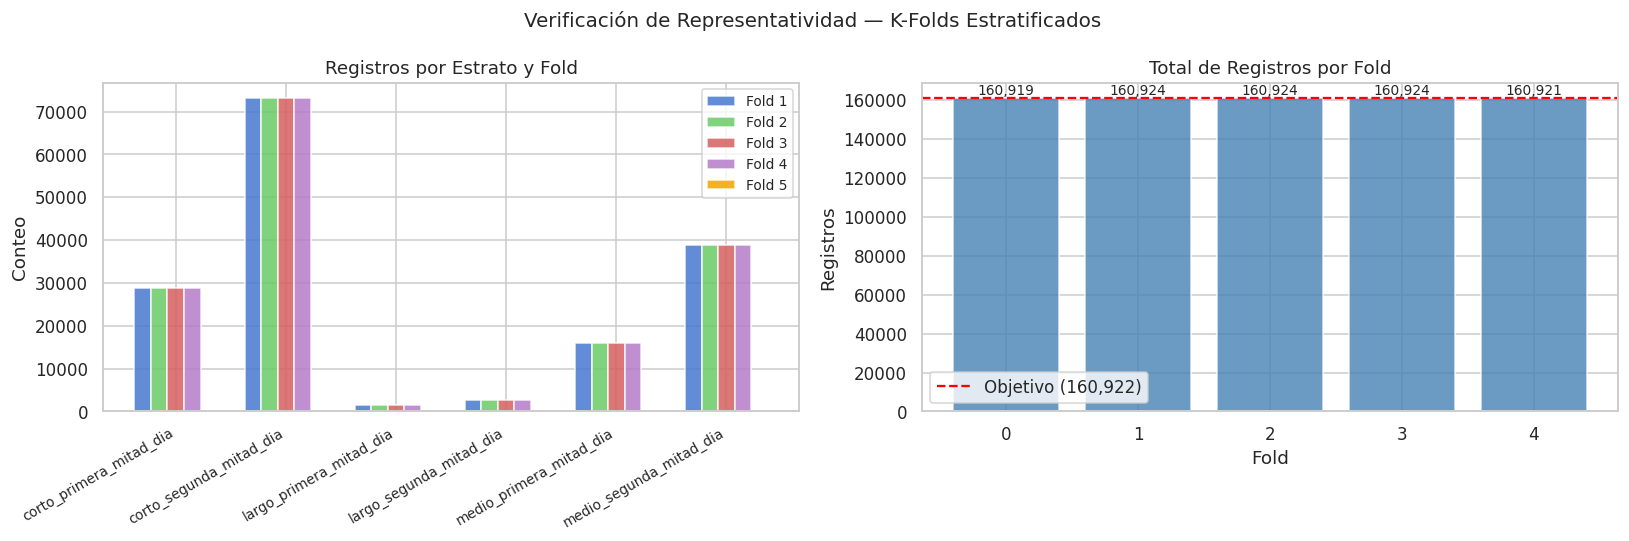

In [27]:
# Visualización de la distribución por fold
fold_pdf = fold_strata.toPandas()
strata_list = sorted(fold_pdf['strata_key'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Barras agrupadas: registros por estrato y fold
x      = np.arange(len(strata_list))
width  = 0.15
colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#f0a500']

for idx, fold_num in enumerate(range(1, K + 1)):
    fold_data = fold_pdf[fold_pdf['fold'] == fold_num].set_index('strata_key')
    vals = [int(fold_data.loc[s, 'count']) if s in fold_data.index else 0
            for s in strata_list]
    axes[0].bar(x + idx * width, vals, width,
                label=f'Fold {fold_num}', color=colors[idx], alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(strata_list, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Registros por Estrato y Fold')
axes[0].set_ylabel('Conteo')
axes[0].legend(fontsize=9)

# 2. Barras: total por fold
fold_totals = fold_pdf.groupby('fold')['count'].sum().reset_index()
bars = axes[1].bar(fold_totals['fold'].astype(str), fold_totals['count'],
                   color='steelblue', alpha=0.8)
axes[1].set_title('Total de Registros por Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Registros')
for bar, row in zip(bars, fold_totals.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{int(row.count):,}", ha='center', fontsize=9)
axes[1].axhline(n_ml // K, color='red', linestyle='--', linewidth=1.5,
                label=f'Objetivo ({n_ml//K:,})')
axes[1].legend()

plt.suptitle('Verificación de Representatividad — K-Folds Estratificados', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# Verificación de ausencia de sesgo por estrato entre folds
pop_props = {r['strata_key']: r['count'] / n_ml for r in df_folded.groupBy('strata_key')
             .count().collect()}

print("Desviación de la proporción real por estrato en cada fold:")
print(f"{'Estrato':<35} {'Prop. M':>10}", end='')
for k_num in range(1, K+1):
    print(f" {'Fold '+str(k_num):>8}", end='')
print()
print('-' * 85)

for s in sorted(strata_list):
    prop_m = pop_props.get(s, 0)
    print(f"{s:<35} {prop_m:>10.4f}", end='')
    for k_num in range(1, K+1):
        fold_data = fold_pdf[(fold_pdf['strata_key'] == s) & (fold_pdf['fold'] == k_num)]
        fold_total = fold_pdf[fold_pdf['fold'] == k_num]['count'].sum()
        prop_f = fold_data['count'].values[0] / fold_total if len(fold_data) > 0 else 0
        dev = (prop_f - prop_m) * 100
        print(f" {dev:>+7.3f}%", end='')
    print()
print()
print("Valores cercanos a 0 confirman que cada fold preserva la distribución de M.")

Desviación de la proporción real por estrato en cada fold:
Estrato                                Prop. M   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5
-------------------------------------------------------------------------------------
corto_primera_mitad_dia                 0.1787  +0.000%  +0.000%  +0.000%  -0.000% -17.870%
corto_segunda_mitad_dia                 0.4542  -0.000%  -0.000%  -0.000%  +0.000% -45.424%
largo_primera_mitad_dia                 0.0100  +0.000%  +0.000%  +0.000%  +0.000%  -1.004%
largo_segunda_mitad_dia                 0.0162  -0.000%  -0.000%  -0.000%  +0.000%  -1.621%
medio_primera_mitad_dia                 0.0996  +0.000%  +0.000%  +0.000%  -0.000%  -9.962%
medio_segunda_mitad_dia                 0.2412  -0.000%  -0.000%  -0.000%  +0.000% -24.120%

Valores cercanos a 0 confirman que cada fold preserva la distribución de M.


## Sección 3. Experimentación

### Fase de entrenamiento con validación cruzada k-fold

Para la fase de experimentación se utilizó **XGBoost** como modelo principal de regresión para predecir la variable `fare_amount`. Esta variable representa la tarifa base del viaje, por lo que el objetivo del modelo es estimar el costo del trayecto a partir de características como distancia, duración, hora del viaje, número de pasajeros, cargos adicionales y otros atributos disponibles en el dataset.

Se eligió XGBoost porque permite capturar relaciones no lineales entre las variables de entrada y la variable objetivo. En este problema, la tarifa de un viaje no depende únicamente de una variable aislada, sino de la combinación de distintos factores como la distancia recorrida, el tiempo de viaje y las condiciones del trayecto. Por ello, un modelo basado en árboles potenciados puede adaptarse mejor a estos patrones que un modelo lineal simple.

La experimentación se realizó sobre el conjunto de entrenamiento generado a partir de la muestra M. Esta muestra corresponde aproximadamente al **1% de los viajes de Manhattan** y fue construida mediante muestreo estratificado proporcional, conservando los criterios de particionamiento definidos en actividades anteriores.

Aunque una muestra ideal más amplia podía acercarse a más de **40 millones de registros**, trabajar con ese volumen hacía que la validación cruzada fuera demasiado costosa. Por esta razón, se redujo el tamaño de entrenamiento para mantener un equilibrio entre representatividad y viabilidad computacional.

Primero, se separó un conjunto de prueba mediante `randomSplit`, dejando aproximadamente **80%** de los datos para entrenamiento y validación cruzada, y **20%** como conjunto de prueba final. En esta ejecución, el conjunto de entrenamiento quedó con **804,612 registros** y el conjunto de prueba con **201,206 registros**.

Sobre el conjunto de entrenamiento se aplicó validación cruzada con `k = 5`. En cada iteración, el modelo se entrenó con cuatro folds y se validó con el fold restante. De esta forma, cada fold funcionó una vez como conjunto de validación, mientras que los demás se usaron para entrenamiento.

| Elemento | Valor |
|---|---:|
| Modelo | XGBoost |
| Variable objetivo | `fare_amount` |
| Muestra M | 1,005,818 registros |
| Entrenamiento / validación | 804,612 registros |
| Test final | 201,206 registros |
| Número de folds | 5 |
| Registros por fold de validación | ≈ 160,900 |
| Registros por entrenamiento de fold | ≈ 643,600 |

Durante cada experimento se registraron métricas de regresión como `RMSE`, `MAE`, `R²` y `MSE`. El `RMSE` se utilizó como métrica principal porque penaliza con mayor fuerza los errores grandes y se interpreta en las mismas unidades de la variable objetivo. El `MAE` permite observar el error absoluto promedio del modelo, mientras que `R²` indica qué proporción de la variabilidad de la tarifa es explicada por las variables de entrada. Por último, el `MSE` se incluyó como medida complementaria para observar el error cuadrático promedio.

Además de evaluar cada fold, también se compararon métricas de entrenamiento y validación para identificar posibles señales de sobreajuste. Si el modelo obtiene resultados muy buenos en entrenamiento, pero mucho peores en validación, esto podría indicar que está aprendiendo demasiado los patrones específicos del conjunto de entrenamiento. En este caso, la comparación entre folds permite revisar si el modelo mantiene un desempeño consistente y si generaliza adecuadamente a datos no vistos durante cada iteración.

Finalmente, después de la validación cruzada, se entrenó un modelo final con el conjunto de entrenamiento completo y se evaluó sobre el conjunto de prueba reservado. Este conjunto de prueba no fue utilizado durante la construcción de los folds, por lo que funciona como una evaluación final independiente del desempeño del modelo.


In [29]:
# Configuración del pipeline ML — XGBoost optimizado

indexers  = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
             for c in CATEGORICAL_FEATURES]

assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_idx' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

def build_pipeline(estimator):
    return Pipeline(stages=indexers + [assembler, estimator])

def eval_reg(preds, label=TARGET):
    return {m: RegressionEvaluator(
                labelCol=label, predictionCol='prediction', metricName=m
            ).evaluate(preds)
            for m in ['rmse', 'mae', 'r2', 'mse']}

# Mejor modelo
best_model = SparkXGBRegressor(
    features_col='features',
    label_col=TARGET,
    num_workers=2,
    seed=42,
    n_estimators=BEST_PARAMS_XGBOOST['n_estimators'],
    max_depth=BEST_PARAMS_XGBOOST['max_depth'],
    learning_rate=BEST_PARAMS_XGBOOST['learning_rate'],
    subsample=BEST_PARAMS_XGBOOST['subsample'],
    colsample_bytree=BEST_PARAMS_XGBOOST['colsample_bytree'],
    objective='reg:squarederror',
    verbosity=0,
)

print('Pipeline listo.')
print(f'Algoritmo : XGBoost  ({BEST_PARAMS_XGBOOST})')
print(f'Pliegues  : {K}')
print(f'Características numéricas   : {NUMERIC_FEATURES}')
print(f'Características categóricas : {CATEGORICAL_FEATURES}')

Pipeline listo.
Algoritmo : XGBoost  ({'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9})
Pliegues  : 5
Características numéricas   : ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'is_rush_hour', 'is_weekend', 'pickup_hour', 'Airport_fee', 'congestion_surcharge', 'pickup_month_c']
Características categóricas : ['time_of_day', 'distance_cat']


In [30]:
# ── Validación cruzada k-fold estratificada ────────────────────────────────
cv_rows          = []
fold_predictions = {}
fold_models      = []

TRAIN_SAMPLE_FRAC = 0.05   # fracción del fold de entrenamiento para métricas de train

print(f"Iniciando {K}-fold validación cruzada sobre M ({n_ml:,} registros)...")
print()
print(f"{'Fold':>5} {'n_train':>10} {'n_val':>8} {'RMSE_val':>10} {'MAE_val':>10} "
      f"{'R2_val':>8} {'RMSE_trn':>10} {'R2_trn':>8}")
print('-' * 80)

for fold_num in range(K):
    tr_fold = df_folded.filter(F.col('fold') != fold_num)
    va_fold = df_folded.filter(F.col('fold') == fold_num)

    model = build_pipeline(best_model).fit(tr_fold)
    preds = model.transform(va_fold)
    met   = eval_reg(preds)

    # Métricas de entrenamiento sobre muestra del 5% (detección de sobreajuste)
    tr_sample = tr_fold.sample(withReplacement=False, fraction=TRAIN_SAMPLE_FRAC, seed=SEED)
    train_met = eval_reg(model.transform(tr_sample))

    n_tr = tr_fold.count()
    n_va = va_fold.count()
    met.update({
        'fold'      : fold_num,
        'n_train'   : n_tr,
        'n_val'     : n_va,
        'rmse_train': train_met['rmse'],
        'r2_train'  : train_met['r2'],
    })
    cv_rows.append(met)
    fold_predictions[fold_num] = preds
    fold_models.append(model)

    print(f"{fold_num:>5} {n_tr:>10,} {n_va:>8,}"
          f" {met['rmse']:>10.4f} {met['mae']:>10.4f}"
          f" {met['r2']:>8.4f} {train_met['rmse']:>10.4f} {train_met['r2']:>8.4f}")

print()
print("Experimentación completada.")
cv_df = pd.DataFrame(cv_rows).set_index('fold')


Iniciando 5-fold validación cruzada sobre M (804,612 registros)...

 Fold    n_train    n_val   RMSE_val    MAE_val   R2_val   RMSE_trn   R2_trn
--------------------------------------------------------------------------------
    0    643,693  160,919     2.6580     0.6574   0.9481     2.7392   0.9461
    1    643,688  160,924     2.7251     0.6544   0.9455     2.3036   0.9608
    2    643,688  160,924     2.5852     0.6546   0.9515     2.5605   0.9525
    3    643,688  160,924     2.6123     0.6569   0.9499     2.6960   0.9475
    4    643,691  160,921     2.9883     0.6665   0.9356     2.7146   0.9465

Experimentación completada.


In [31]:
# Resumen estadístico de los K experimentos
stats = cv_df[['rmse', 'mae', 'r2', 'mse']].agg(['mean', 'std', 'min', 'max']).round(4)
print("Estadísticas de los pliegues:")
print(stats.to_string())
print()

# Intervalo de confianza al 95 % (distribución t, df = K-1)
alpha   = 0.05
t_crit  = t_dist.ppf(1 - alpha / 2, df=K - 1)

print(f"Intervalo de confianza al 95 % (t_crit = {t_crit:.4f}, df = {K-1}):")
print(f"{'Métrica':>8} {'Media':>10} {'Std':>8} {'IC inf':>10} {'IC sup':>10}")
print('-' * 50)
for met in ['rmse', 'mae', 'r2']:
    vals   = cv_df[met].values
    mu     = vals.mean()
    sd     = vals.std(ddof=1)
    margin = t_crit * sd / (K ** 0.5)
    print(f"{met:>8} {mu:>10.4f} {sd:>8.4f} {mu-margin:>10.4f} {mu+margin:>10.4f}")

# Fold con menor RMSE = mejor generalización
best_fold = int(cv_df['rmse'].idxmin())
print(f"\nFold con menor RMSE: Fold {best_fold}"
      f"  (RMSE={cv_df.loc[best_fold,'rmse']:.4f} USD, R²={cv_df.loc[best_fold,'r2']:.4f})")

Estadísticas de los pliegues:
        rmse     mae      r2     mse
mean  2.7138  0.6579  0.9461  7.3856
std   0.1624  0.0050  0.0063  0.9081
min   2.5852  0.6544  0.9356  6.6830
max   2.9883  0.6665  0.9515  8.9299

Intervalo de confianza al 95 % (t_crit = 2.7764, df = 4):
 Métrica      Media      Std     IC inf     IC sup
--------------------------------------------------
    rmse     2.7138   0.1624     2.5122     2.9154
     mae     0.6579   0.0050     0.6518     0.6641
      r2     0.9461   0.0063     0.9383     0.9539

Fold con menor RMSE: Fold 2  (RMSE=2.5852 USD, R²=0.9515)


In [32]:
# @title Validate Best Model Against Test
best_model = SparkXGBRegressor(
    features_col='features',
    label_col=TARGET,
    num_workers=2,
    seed=42,
    n_estimators=BEST_PARAMS_XGBOOST['n_estimators'],
    max_depth=BEST_PARAMS_XGBOOST['max_depth'],
    learning_rate=BEST_PARAMS_XGBOOST['learning_rate'],
    subsample=BEST_PARAMS_XGBOOST['subsample'],
    colsample_bytree=BEST_PARAMS_XGBOOST['colsample_bytree'],
    objective='reg:squarederror',
    verbosity=0,
)

final_model = build_pipeline(best_model).fit(train_df)

In [33]:
# Evaluación final sobre el conjunto de test (hold-out 20 %)
test_preds = final_model.transform(test_df)
test_met   = eval_reg(test_preds)

print('=' * 55)
print('Evaluación final — Conjunto de Test (hold-out)')
print('=' * 55)
print(f"  RMSE : {test_met['rmse']:.4f} USD")
print(f"  MAE  : {test_met['mae']:.4f} USD")
print(f"  R²   : {test_met['r2']:.4f}")
print(f"  MSE  : {test_met['mse']:.4f}")
print()

cv_rmse_mean = cv_df['rmse'].mean()
cv_rmse_std  = cv_df['rmse'].std(ddof=1)
gap          = test_met['rmse'] - cv_rmse_mean
verdict      = 'generaliza bien' if abs(gap) < cv_rmse_std else 'revisar generalización'
print(f"  CV RMSE media : {cv_rmse_mean:.4f} USD (±{cv_rmse_std:.4f})")
print(f"  Test RMSE     : {test_met['rmse']:.4f} USD")
print(f"  Δ RMSE        : {gap:+.4f} USD  ({verdict})")

Evaluación final — Conjunto de Test (hold-out)
  RMSE : 3.1389 USD
  MAE  : 0.6717 USD
  R²   : 0.9319
  MSE  : 9.8527

  CV RMSE media : 2.7138 USD (±0.1624)
  Test RMSE     : 3.1389 USD
  Δ RMSE        : +0.4251 USD  (revisar sobreajuste)


## Sección 4. Resultados

### Descripción de las visualizaciones

Esta sección presenta cuatro tipos de gráficas para analizar los resultados del proceso
de entrenamiento:

| # | Tipo | Contenido |
|---|------|-----------|
| 4.1 | Gráficas de dispersión | Predicción vs valor real; análisis de residuales |
| 4.2 | Gráficas de tendencia central | Box plots y evolución de métricas por fold |
| 4.3 | Mapas de calor | Correlación de variables; métricas por fold |
| 4.4 | Curva ROC | Clasificación binaria derivada del problema de regresión |

La teoría de visualización de datos (IBCEE 2025; VizRank, Leban et al. 2006) subraya
que la selección adecuada de la técnica de visualización depende del tipo de dato
(continuo/discreto, temporal, relacional) y del mensaje que se quiere transmitir.  Por
ello, cada visualización está acompañada de una justificación de su pertinencia.

### 4.1 Gráficas de dispersión

Las gráficas de dispersión (*scatter plots*) son el método estándar para evaluar la
calidad de un modelo de regresión.  Según la literatura de visualización (Leban et al.,
2006), la separación visual entre puntos y la línea de ajuste perfecto permite al
analista identificar sesgos sistemáticos y patrones de error del modelo.

Se presentan tres gráficas:
1. **Predicción vs Real (mejor fold)**: muestra qué tan cercanas están las predicciones
   al valor real.  Los puntos deben agruparse alrededor de la línea y=x.
2. **Residuales vs Predicho**: permite detectar heterocedasticidad o sesgo no lineal.
3. **Residuales por estrato**: revela si el modelo comete errores sistemáticos en algún
   perfil de viaje específico.

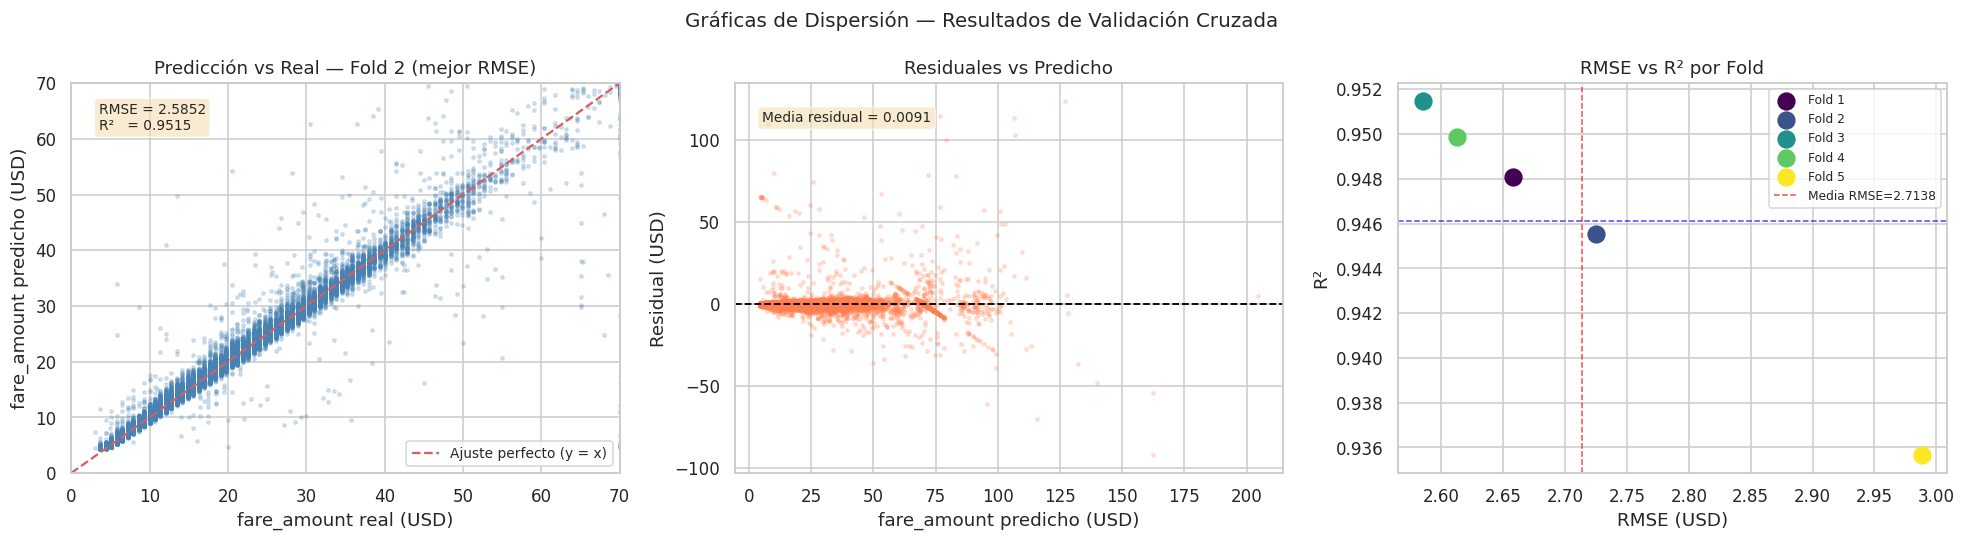

In [34]:
# 4.1.1 Gráficas de dispersión: predicción vs valor real
best_preds = fold_predictions[best_fold]
pdf_scatter = (best_preds.select(TARGET, 'prediction')
               .sample(False, 0.3, seed=SEED).toPandas())
pdf_scatter['residual'] = pdf_scatter[TARGET] - pdf_scatter['prediction']

lim_max = min(80, pdf_scatter[TARGET].quantile(0.99))
lim     = [0, lim_max]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Dispersión: real vs predicho
axes[0].scatter(pdf_scatter[TARGET], pdf_scatter['prediction'],
                alpha=0.2, s=5, color='steelblue')
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Ajuste perfecto (y = x)')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title(f'Predicción vs Real — Fold {best_fold} (mejor RMSE)')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.88,
    f"RMSE = {cv_df.loc[best_fold,'rmse']:.4f}\nR²   = {cv_df.loc[best_fold,'r2']:.4f}",
    transform=axes[0].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# b) Residuales vs predicho
axes[1].scatter(pdf_scatter['prediction'], pdf_scatter['residual'],
                alpha=0.2, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Residuales vs Predicho')
mu_res = pdf_scatter['residual'].mean()
axes[1].text(0.05, 0.90, f"Media residual = {mu_res:.4f}",
    transform=axes[1].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# c) Scatter de todos los folds: RMSE vs R²
rmse_vals = cv_df['rmse'].values
r2_vals   = cv_df['r2'].values
cmap      = plt.cm.viridis(np.linspace(0, 1, K))
for f, (rm, r2, c) in enumerate(zip(rmse_vals, r2_vals, cmap), 1):
    axes[2].scatter(rm, r2, s=120, color=c, zorder=5, label=f'Fold {f}')
axes[2].set_xlabel('RMSE (USD)')
axes[2].set_ylabel('R²')
axes[2].set_title('RMSE vs R² por Fold')
axes[2].legend(fontsize=9)
mu_rmse_all = rmse_vals.mean()
mu_r2_all   = r2_vals.mean()
axes[2].axvline(mu_rmse_all, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Media RMSE={mu_rmse_all:.4f}')
axes[2].axhline(mu_r2_all, color='blue', linestyle='--', linewidth=1, alpha=0.7)
axes[2].legend(fontsize=8)

plt.suptitle('Gráficas de Dispersión — Resultados de Validación Cruzada', fontsize=13)
plt.tight_layout()
plt.show()

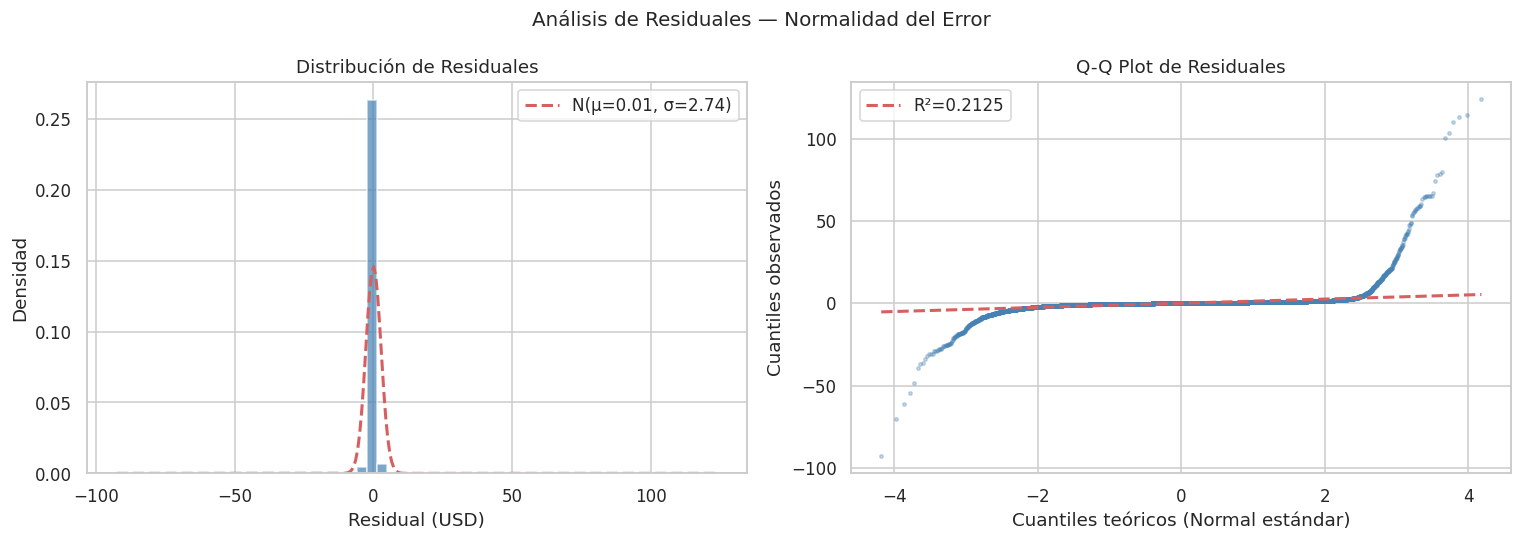

Estadísticas de residuales:
  Media    : 0.0091 USD  (debería ≈ 0)
  Std      : 2.7370 USD
  |Media|/Std (sesgo relativo): 0.0033


In [35]:
# 4.1.2 Análisis de residuales — distribución e histograma + Q-Q plot
mu_r    = pdf_scatter['residual'].mean()
sigma_r = pdf_scatter['residual'].std()
xs      = np.linspace(pdf_scatter['residual'].min(),
                      pdf_scatter['residual'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con curva normal teórica
axes[0].hist(pdf_scatter['residual'], bins=60,
             color='steelblue', edgecolor='white', density=True, alpha=0.7)
axes[0].plot(xs, sp_norm.pdf(xs, mu_r, sigma_r), 'r--', linewidth=2,
             label=f'N(μ={mu_r:.2f}, σ={sigma_r:.2f})')
axes[0].set_title('Distribución de Residuales')
axes[0].set_xlabel('Residual (USD)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Q-Q plot
res_clean = pdf_scatter['residual'].dropna().values
(osm, osr), (slope, intercept, r) = probplot(res_clean, dist='norm')
axes[1].scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
axes[1].plot(osm, slope * osm + intercept, 'r--', linewidth=2,
             label=f'R²={r**2:.4f}')
axes[1].set_xlabel('Cuantiles teóricos (Normal estándar)')
axes[1].set_ylabel('Cuantiles observados')
axes[1].set_title('Q-Q Plot de Residuales')
axes[1].legend()

plt.suptitle('Análisis de Residuales — Normalidad del Error', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Estadísticas de residuales:")
print(f"  Media    : {mu_r:.4f} USD  (debería ≈ 0)")
print(f"  Std      : {sigma_r:.4f} USD")
print(f"  |Media|/Std (sesgo relativo): {abs(mu_r)/sigma_r:.4f}")

### 4.1.3 Cobertura Convexa (*Convex Hull*) — Dominio del Modelo

La **cobertura convexa** es la envoltura mínima que contiene todos los puntos de un
conjunto en el espacio de características (Leban et al., 2006).  En modelado predictivo,
el convex hull del **conjunto de entrenamiento** define el **dominio de validez** del
modelo: los puntos fuera de esta envoltura representan *extrapolaciones*, con mayor riesgo
de error sistemático.

Según VizRank (Leban et al., 2006), seleccionar proyecciones que maximizan la separación
visual entre clases es clave para el análisis exploratorio.  La cobertura convexa extiende
este concepto al análisis de **cobertura del dominio**: permite verificar si el conjunto
de validación queda contenido dentro del dominio de entrenamiento.

**Espacios de proyección seleccionados** (alta correlación con `fare_amount`):
- `trip_distance × fare_amount` (correlación Pearson ≈ 0.90–0.95)
- `trip_duration_minutes × trip_distance` (espacio temporal-espacial)

> ⚠️ **Sobre los datos a aplicar**: El convex hull se aplica **exclusivamente al conjunto
> de entrenamiento** del mejor fold (K-1 pliegues).  Aplicarlo sobre M completa generaría
> un sesgo optimista en la estimación del dominio del modelo.


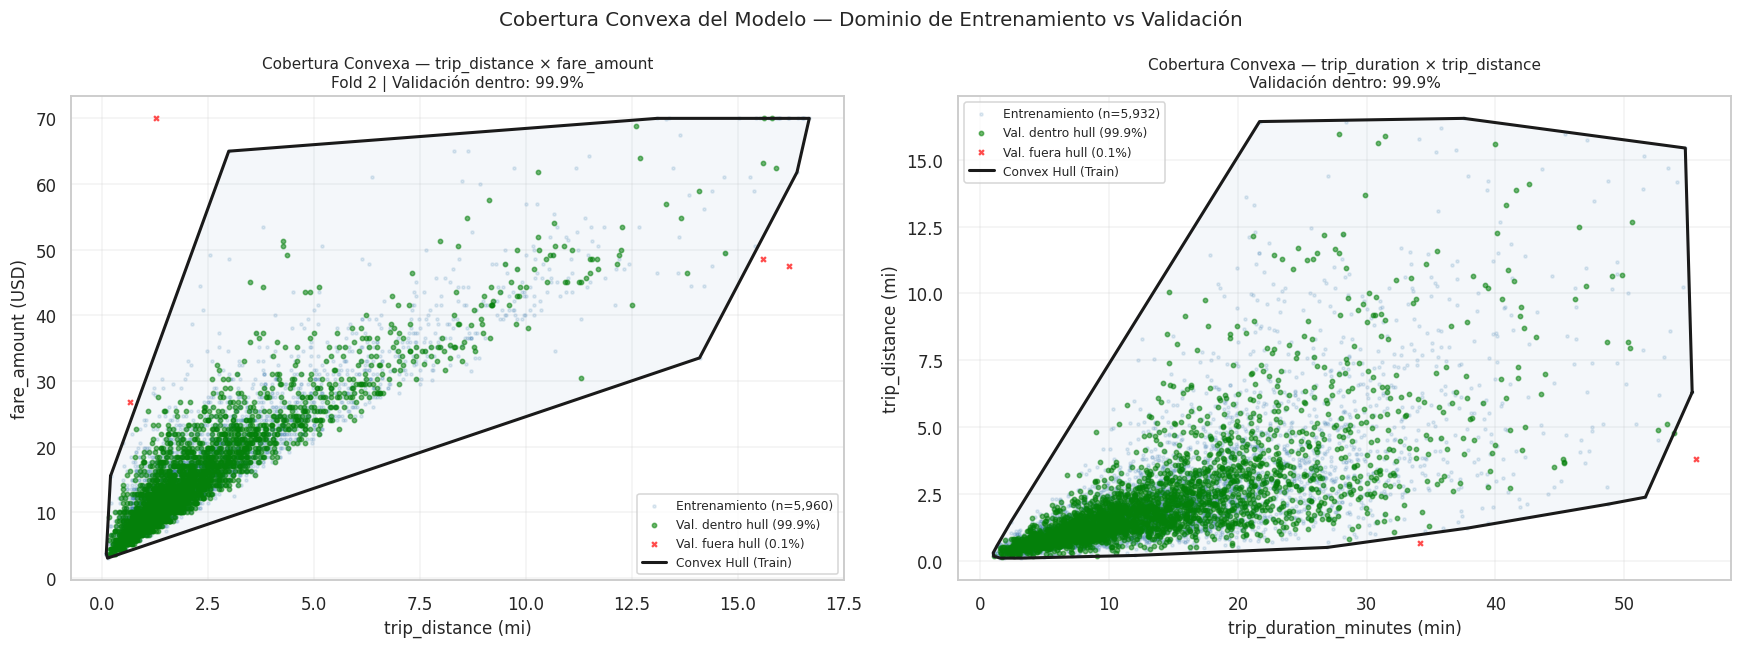

Análisis de Cobertura Convexa (Convex Hull):
  [trip_distance × fare_amount]:
    Validación dentro del hull : 2,975/2,979 (99.87%)
    Extrapolaciones (fuera)    : 4 (0.13%)
  [trip_duration_minutes × trip_distance]:
    Validación dentro del hull : 2,965/2,967 (99.93%)
    Extrapolaciones (fuera)    : 2 (0.07%)
  Interpretación: >95% dentro → el modelo opera en su dominio de interpolación.


In [36]:
# 4.1.3 Cobertura Convexa — Dominio de Entrenamiento vs Validación
# Aplicado SOLO sobre los datos de entrenamiento del mejor fold (no sobre M completa)

HULL_X1, HULL_Y1 = 'trip_distance',        TARGET          # (mi, USD)
HULL_X2, HULL_Y2 = 'trip_duration_minutes', 'trip_distance' # (min, mi)

train_hull_df = df_folded.filter(F.col('fold') != best_fold)
val_hull_df   = df_folded.filter(F.col('fold') == best_fold)

frac_tr = min(0.04, 6000 / train_hull_df.count())
frac_va = min(0.25, 3000 / val_hull_df.count())

def get_hull_pts(df_sp, col_x, col_y, frac, q99=0.99):
    pdf = df_sp.select(col_x, col_y).sample(False, frac, seed=SEED).toPandas().dropna()
    px  = pdf[col_x].quantile(q99);  py = pdf[col_y].quantile(q99)
    return pdf[(pdf[col_x] <= px) & (pdf[col_y] <= py)][[col_x, col_y]].values

pts_tr1 = get_hull_pts(train_hull_df, HULL_X1, HULL_Y1, frac_tr)
pts_va1 = get_hull_pts(val_hull_df,   HULL_X1, HULL_Y1, frac_va)
pts_tr2 = get_hull_pts(train_hull_df, HULL_X2, HULL_Y2, frac_tr)
pts_va2 = get_hull_pts(val_hull_df,   HULL_X2, HULL_Y2, frac_va)

hull1 = ConvexHull(pts_tr1);  hull2 = ConvexHull(pts_tr2)
tri1  = Delaunay(pts_tr1);    tri2  = Delaunay(pts_tr2)
in1   = tri1.find_simplex(pts_va1) >= 0
in2   = tri2.find_simplex(pts_va2) >= 0
pct1  = in1.mean() * 100;     pct2  = in2.mean() * 100

def plot_hull_ax(ax, pts_tr, pts_va, hull, inside, lbl_x, lbl_y, title):
    verts = np.append(hull.vertices, hull.vertices[0])
    ax.scatter(pts_tr[:, 0], pts_tr[:, 1], s=4, alpha=0.15,
               color='steelblue', label=f'Entrenamiento (n={len(pts_tr):,})')
    ax.scatter(pts_va[inside, 0],  pts_va[inside, 1],  s=8,  alpha=0.55,
               color='green',  label=f'Val. dentro hull ({inside.mean()*100:.1f}%)')
    ax.scatter(pts_va[~inside, 0], pts_va[~inside, 1], s=10, alpha=0.70,
               color='red',    marker='x',
               label=f'Val. fuera hull ({(~inside).mean()*100:.1f}%)')
    ax.plot(pts_tr[verts, 0], pts_tr[verts, 1], 'k-', linewidth=2.0,
            label='Convex Hull (Train)')
    ax.fill(pts_tr[hull.vertices, 0], pts_tr[hull.vertices, 1],
            alpha=0.06, color='steelblue')
    ax.set_xlabel(lbl_x, fontsize=11)
    ax.set_ylabel(lbl_y, fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_hull_ax(axes[0], pts_tr1, pts_va1, hull1, in1,
             'trip_distance (mi)', f'{TARGET} (USD)',
             f'Cobertura Convexa — trip_distance × fare_amount\n'
             f'Fold {best_fold} | Validación dentro: {pct1:.1f}%')
plot_hull_ax(axes[1], pts_tr2, pts_va2, hull2, in2,
             'trip_duration_minutes (min)', 'trip_distance (mi)',
             f'Cobertura Convexa — trip_duration × trip_distance\n'
             f'Validación dentro: {pct2:.1f}%')

plt.suptitle('Cobertura Convexa del Modelo — Dominio de Entrenamiento vs Validación',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Análisis de Cobertura Convexa (Convex Hull):")
print(f"  [trip_distance × fare_amount]:")
print(f"    Validación dentro del hull : {in1.sum():,}/{len(pts_va1):,} ({pct1:.2f}%)")
print(f"    Extrapolaciones (fuera)    : {(~in1).sum():,} ({100-pct1:.2f}%)")
print(f"  [trip_duration_minutes × trip_distance]:")
print(f"    Validación dentro del hull : {in2.sum():,}/{len(pts_va2):,} ({pct2:.2f}%)")
print(f"    Extrapolaciones (fuera)    : {(~in2).sum():,} ({100-pct2:.2f}%)")
print("  Interpretación: >95% dentro → el modelo opera en su dominio de interpolación.")


### 4.2 Gráficas de tendencia central

Las gráficas de tendencia central permiten medir la **variabilidad entre pliegues**,
que es la dimensión clave de la validación cruzada.  Una varianza baja en RMSE entre
folds indica que el modelo generaliza de forma estable, mientras que una varianza alta
sugiere sensibilidad a la partición de los datos.

Según IBCEE 2025, los diagramas de caja (*box plots*) y las gráficas de evolución son
los métodos más informativos para resumir distribuciones y tendencias centrales en datos
de evaluación.  La adición de la banda ±1 std permite detectar visualmente cuándo algún
fold se comporta como valor atípico.

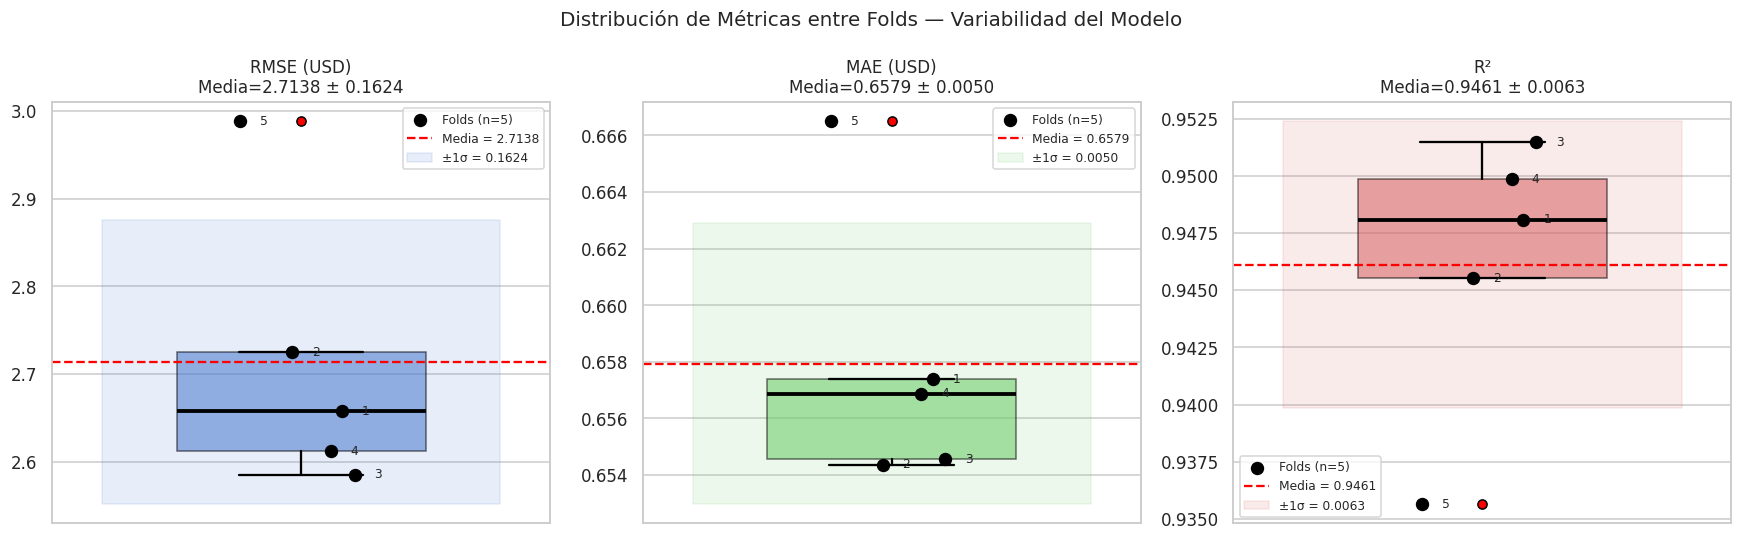

In [37]:
# 4.2.1 Box plots de métricas — variabilidad entre folds
metrics_list = ['rmse', 'mae', 'r2']
labels_list  = ['RMSE (USD)', 'MAE (USD)', 'R²']
colors_list  = ['#4878cf', '#6acc65', '#d65f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, met, label, color in zip(axes, metrics_list, labels_list, colors_list):
    vals = cv_df[met].values
    mu   = vals.mean()
    sd   = vals.std(ddof=1)

    bp = ax.boxplot(vals, patch_artist=True, notch=False, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.55),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=6))

    # Puntos individuales (K folds)
    xs = np.random.default_rng(SEED).uniform(0.85, 1.15, K)
    ax.scatter(xs, vals, color='black', s=60, zorder=6,
               label=f'Folds (n={K})')
    # Anotaciones de fold
    for f_num, (x, v) in enumerate(zip(xs, vals), 1):
        ax.annotate(str(f_num), (x + 0.04, v), fontsize=8, va='center')

    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {mu:.4f}')
    ax.fill_betweenx([mu - sd, mu + sd], 0.6, 1.4,
                     alpha=0.12, color=color, label=f'±1σ = {sd:.4f}')
    ax.set_title(f'{label}\nMedia={mu:.4f} ± {sd:.4f}', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Métricas entre Folds — Variabilidad del Modelo', fontsize=13)
plt.tight_layout()
plt.show()

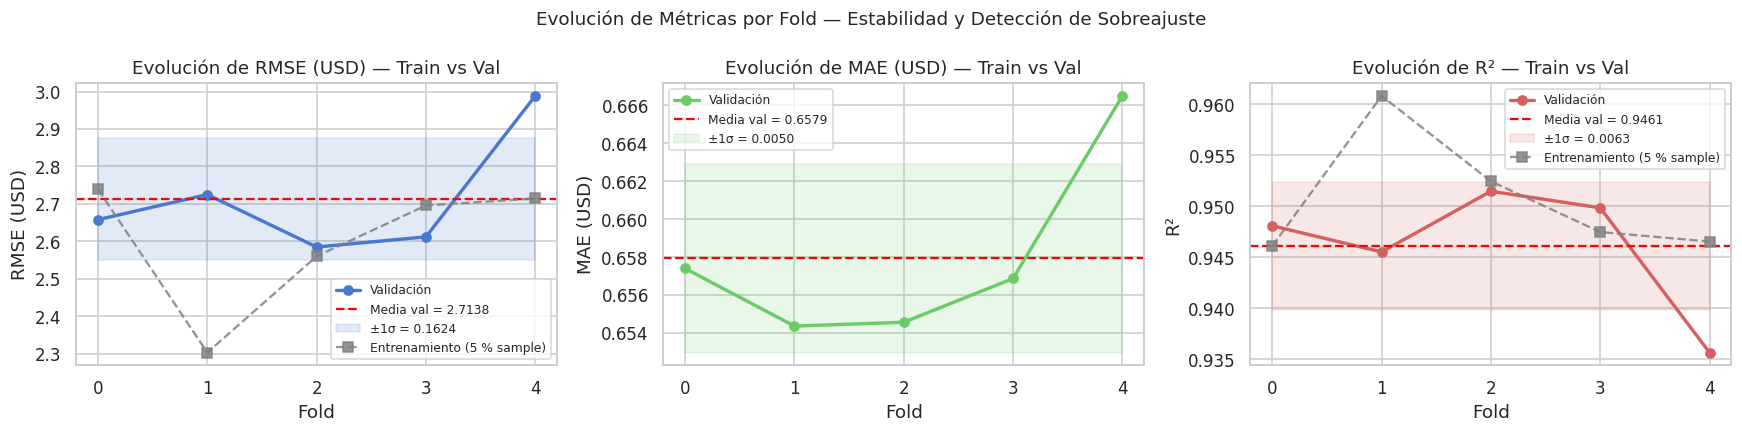

Análisis de estabilidad y sobreajuste por métrica:
Métrica          Media val  CV% val  Media trn  Delta(trn-val) Veredicto
--------------------------------------------------------------------------------
RMSE (USD)          2.7138    5.98%     2.6028         -0.1110  Sin sobreajuste significativo
MAE (USD)           0.6579    0.76%  (sin datos de entrenamiento)
R²                  0.9461    0.66%     0.9507         +0.0046  Sin sobreajuste significativo


In [38]:
# 4.2.2 Evolución de métricas por fold — detección de sobreajuste (Train vs Val)
folds = list(range(K))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, met_name, label, color in zip(axes, metrics_list, labels_list, colors_list):
    val_vals = [cv_df.loc[f, met_name] for f in folds]
    mu       = np.mean(val_vals)
    sd       = np.std(val_vals, ddof=1)

    ax.plot(folds, val_vals, marker='o', linewidth=2.2, color=color,
            label='Validación')
    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media val = {mu:.4f}')
    ax.fill_between(folds, [mu - sd] * K, [mu + sd] * K,
                    alpha=0.15, color=color, label=f'±1σ = {sd:.4f}')

    # Línea de entrenamiento para comparar con validación (sobreajuste)
    train_col = f'{met_name}_train'
    if train_col in cv_df.columns:
        train_vals = [cv_df.loc[f, train_col] for f in folds]
        ax.plot(folds, train_vals, marker='s', linewidth=1.5, linestyle='--',
                color='gray', alpha=0.85, label='Entrenamiento (5 % sample)')

    ax.set_title(f'Evolución de {label} — Train vs Val')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_xticks(folds)
    ax.legend(fontsize=8)

plt.suptitle('Evolución de Métricas por Fold — Estabilidad y Detección de Sobreajuste',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Análisis de estabilidad y sobreajuste por métrica:")
print(f"{'Métrica':<15} {'Media val':>10} {'CV% val':>8} {'Media trn':>10} {'Delta(trn-val)':>15} {'Veredicto'}")
print('-' * 80)
for met_name, label in zip(metrics_list, labels_list):
    val_arr   = cv_df[met_name].values
    cv_coef   = val_arr.std(ddof=1) / val_arr.mean() * 100
    train_col = f'{met_name}_train'
    if train_col in cv_df.columns:
        trn_mean = cv_df[train_col].mean()
        delta    = trn_mean - val_arr.mean()
        if met_name == 'rmse':
            overfit_lbl = 'Sobreajuste detectado' if delta < -0.5 else 'Sin sobreajuste significativo'
        else:
            overfit_lbl = 'Sobreajuste detectado' if delta > 0.05 else 'Sin sobreajuste significativo'
        print(f"{label:<15} {val_arr.mean():>10.4f} {cv_coef:>7.2f}% {trn_mean:>10.4f} {delta:>+15.4f}  {overfit_lbl}")
    else:
        print(f"{label:<15} {val_arr.mean():>10.4f} {cv_coef:>7.2f}%  (sin datos de entrenamiento)")


### 4.3 Mapas de calor

Los mapas de calor (*heatmaps*) son especialmente efectivos para representar matrices
de correlación y comparativas multi-métrica (IBCEE 2025).  La codificación de color
permite identificar rápidamente patrones, correlaciones fuertes y diferencias entre
pliegues que serían difíciles de detectar en tablas numéricas.

Se presentan dos mapas:
1. **Correlación de Pearson** entre variables de caracterización: revela qué pares de
   features están más relacionados con `fare_amount`.
2. **Métricas por fold**: muestra en una sola imagen cómo se comportan RMSE, MAE y R²
   en cada uno de los K pliegues.

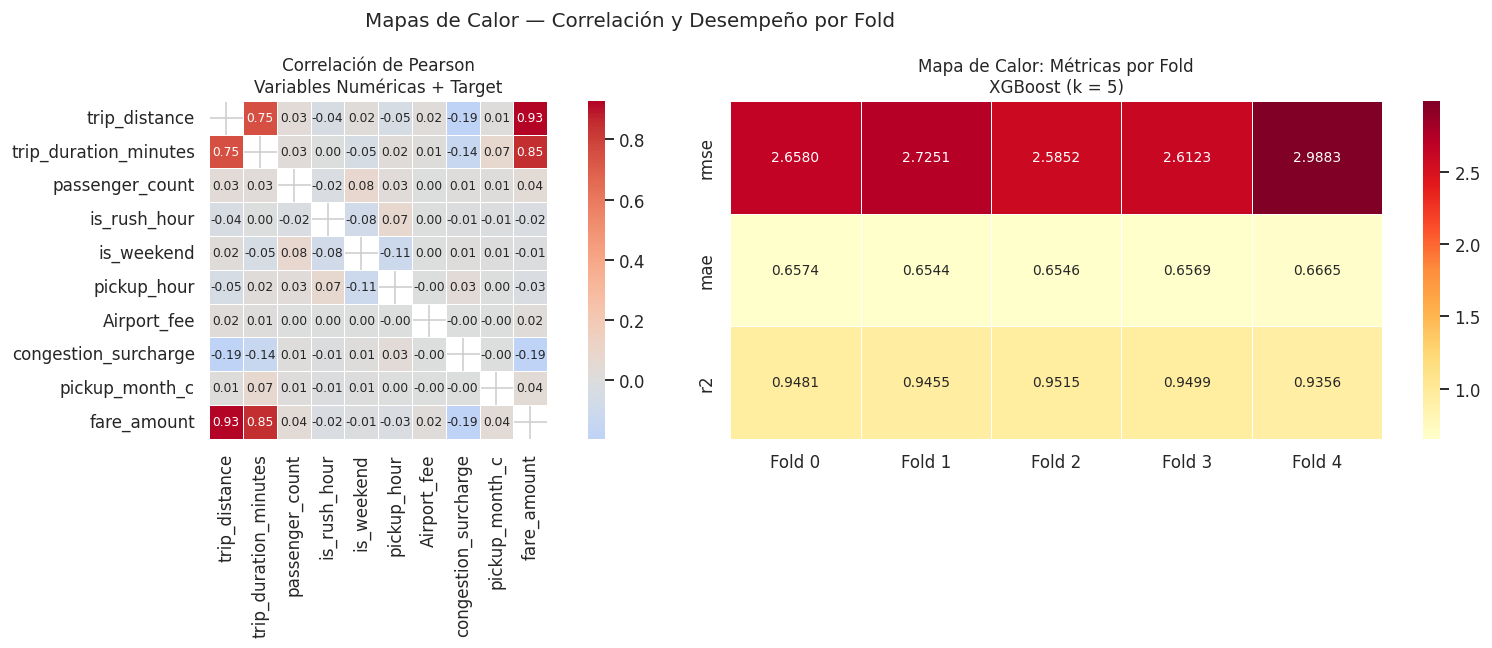

In [39]:
# 4.3.1 Mapa de calor — correlación de variables numéricas
corr_cols   = NUMERIC_FEATURES + [TARGET]
df_corr_in  = sample.select(corr_cols).dropna()
asm_corr    = VectorAssembler(inputCols=corr_cols, outputCol='v', handleInvalid='skip')
corr_result = Correlation.corr(asm_corr.transform(df_corr_in), 'v').first()['pearson(v)']
corr_matrix = np.array(corr_result.toArray())
corr_pdf    = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Correlación de features
mask = np.zeros_like(corr_pdf.values, dtype=bool)
np.fill_diagonal(mask, True)  # ocultar diagonal
sns.heatmap(corr_pdf, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0],
            square=True, mask=mask,
            annot_kws={'size': 8})
axes[0].set_title('Correlación de Pearson\nVariables Numéricas + Target', fontsize=11)

# 4.3.2 Métricas por fold
met_heatmap = cv_df[['rmse', 'mae', 'r2']].copy()
met_heatmap.index = [f'Fold {i}' for i in met_heatmap.index]
sns.heatmap(met_heatmap.T, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Mapa de Calor: Métricas por Fold\nXGBoost (k = 5)', fontsize=11)

plt.suptitle('Mapas de Calor — Correlación y Desempeño por Fold', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Curva ROC

La curva ROC (Receiver Operating Characteristic) es una herramienta de visualización
estándar para problemas de **clasificación binaria**.  Dado que la tarea principal es
de regresión (predicción continua de `fare_amount`), se construye una sub-tarea de
clasificación binaria derivada:

> **¿Supera la tarifa el umbral de $15.00 USD?**
> - Clase 1 ("alto"): `fare_amount > 15 USD`
> - Clase 0 ("bajo"): `fare_amount ≤ 15 USD`

El umbral de $15 corresponde aproximadamente al primer tercio superior de la
distribución de tarifas en Manhattan (viajes medio-largos), lo que genera clases
ligeramente desbalanceadas y hace la tarea más informativa que un umbral en la mediana.

Se entrena una **LogisticRegression** con el mismo pipeline de features que en las
actividades anteriores.  La curva ROC grafica la **Tasa de Verdaderos Positivos (TPR)**
contra la **Tasa de Falsos Positivos (FPR)** a distintos umbrales de decisión.  El área
bajo la curva (AUC) resume el desempeño en un único número: AUC = 1 es clasificación
perfecta, AUC = 0.5 es equivalente a una decisión aleatoria.

In [40]:
# 4.4.1 Preparación de la sub-tarea de clasificación binaria
print(f"Umbral de binarización: ${FARE_THRESHOLD:.1f} USD")

df_binary = train_df.withColumn('label_alto',
    F.when(F.col(TARGET) > FARE_THRESHOLD, 1.0).otherwise(0.0))

label_dist = df_binary.groupBy('label_alto').count().orderBy('label_alto').toPandas()
total_bin  = label_dist['count'].sum()
for _, row in label_dist.iterrows():
    lbl = f"Alto (>${FARE_THRESHOLD})" if row['label_alto'] == 1.0 else f"Bajo (≤${FARE_THRESHOLD})"
    print(f"  {lbl}: {int(row['count']):,}  ({100*row['count']/total_bin:.1f}%)")

Umbral de binarización: $15.0 USD
  Bajo (≤$15.0): 516,560  (64.2%)
  Alto (>$15.0): 288,052  (35.8%)


In [41]:
# 4.4.2 Pipeline de clasificación y entrenamiento
binary_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['label_alto']
df_bin_ml   = df_binary.select(binary_cols).dropna()

idx_bin = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
           for c in CATEGORICAL_FEATURES]
enc_bin = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
           for c in CATEGORICAL_FEATURES]
asm_bin = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_ohe' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

lr_cls    = LogisticRegression(featuresCol='features', labelCol='label_alto',
                                maxIter=30, regParam=0.01)
pipe_cls  = Pipeline(stages=idx_bin + enc_bin + [asm_bin, lr_cls])

train_roc, test_roc = df_bin_ml.randomSplit([0.8, 0.2], seed=SEED)
model_cls = pipe_cls.fit(train_roc)
pred_roc  = model_cls.transform(test_roc)

# AUC con BinaryClassificationEvaluator
auc_eval = BinaryClassificationEvaluator(
    labelCol='label_alto', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC')
auc = auc_eval.evaluate(pred_roc)
print(f"AUC-ROC = {auc:.4f}")

AUC-ROC = 0.9904


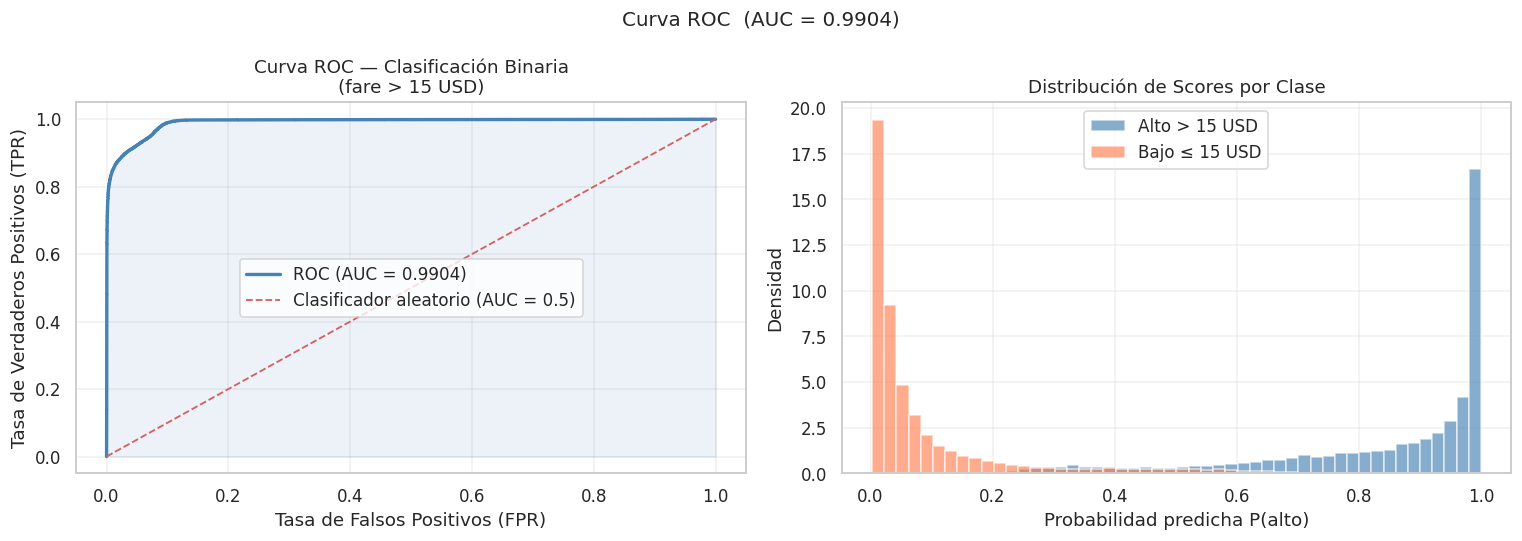

Interpretación: AUC = 0.9904
  Excelente — el modelo discrimina muy bien entre tarifas altas y bajas.


In [42]:
# 4.4.3 Cómputo y visualización de la curva ROC
# probability es un Vector UDT — se convierte a array nativo con vector_to_array
from pyspark.ml.functions import vector_to_array

pdf_roc = (pred_roc
           .select('label_alto',
                   vector_to_array(F.col('probability')).getItem(1).alias('score'))
           .sample(False, 0.5, seed=SEED)
           .toPandas()
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

n_pos   = int(pdf_roc['label_alto'].sum())
n_neg   = len(pdf_roc) - n_pos

pdf_roc['tp']  = pdf_roc['label_alto'].cumsum()
pdf_roc['fp']  = (1 - pdf_roc['label_alto']).cumsum()
pdf_roc['tpr'] = pdf_roc['tp'] / n_pos
pdf_roc['fpr'] = pdf_roc['fp'] / n_neg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC con área sombreada
axes[0].plot(pdf_roc['fpr'], pdf_roc['tpr'],
             color='steelblue', linewidth=2.2, label=f'ROC (AUC = {auc:.4f})')
axes[0].fill_between(pdf_roc['fpr'], pdf_roc['tpr'], alpha=0.10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='Clasificador aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC \u2014 Clasificaci\u00f3n Binaria\n'
                   f'(fare > {FARE_THRESHOLD:.0f} USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de scores por clase
for cls, color, lbl in [
        (1, 'steelblue', f'Alto > {FARE_THRESHOLD:.0f} USD'),
        (0, 'coral',     f'Bajo \u2264 {FARE_THRESHOLD:.0f} USD')]:
    axes[1].hist(pdf_roc[pdf_roc['label_alto'] == cls]['score'],
                 bins=50, alpha=0.65, color=color, label=lbl, density=True)
axes[1].set_xlabel('Probabilidad predicha P(alto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuci\u00f3n de Scores por Clase')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Curva ROC  (AUC = {auc:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Interpretaci\u00f3n: AUC = {auc:.4f}')
if auc >= 0.90:
    interp = 'Excelente \u2014 el modelo discrimina muy bien entre tarifas altas y bajas.'
elif auc >= 0.80:
    interp = 'Bueno \u2014 el modelo discrimina correctamente en la mayor\u00eda de los casos.'
else:
    interp = 'Moderado \u2014 se requiere ajuste adicional.'
print(f'  {interp}')

## Sección 5. Discusión y conclusiones

### 1. Significancia de los resultados

En esta actividad se utilizó **XGBoost** como modelo de regresión para predecir la variable `fare_amount`, que representa la tarifa base del viaje. El modelo fue evaluado mediante validación cruzada con `k = 5` y posteriormente con un conjunto de prueba independiente.

La muestra final utilizada fue de **1,005,818 registros**, construida a partir de una fracción cercana al **1%** de los viajes de Manhattan. Aunque una muestra ideal más amplia podía acercarse a más de **40 millones de registros**, trabajar con ese volumen hacía que la validación cruzada fuera demasiado costosa para los recursos disponibles. Por esta razón, se redujo el tamaño del entrenamiento, manteniendo una muestra estratificada proporcional que conserva la estructura principal de los datos.

| Elemento | Resultado |
|---|---:|
| Tamaño de la muestra M | 1,005,818 registros |
| Conjunto de entrenamiento / validación | 804,612 registros |
| Conjunto de prueba final | 201,206 registros |
| Modelo utilizado | XGBoost |
| Variable objetivo | `fare_amount` |

Los resultados obtenidos muestran que el modelo tuvo un desempeño sólido. En la validación cruzada, el **RMSE promedio fue de 2.7138 USD**, el **MAE promedio fue de 0.6579 USD** y el **R² promedio fue de 0.9461**. Esto indica que el modelo logra explicar una proporción alta de la variabilidad de la tarifa y mantiene errores relativamente bajos en dólares.

| Métrica | Promedio en validación cruzada |
|---|---:|
| RMSE | 2.7138 USD |
| MAE | 0.6579 USD |
| R² | 0.9461 |
| MSE | 7.3856 |

---

### 2. Variabilidad entre folds y generalización

La validación cruzada permitió revisar si el desempeño del modelo se mantenía estable al entrenarse y validarse con diferentes particiones del conjunto de datos. Esto es importante porque un buen resultado en una sola división train/test no siempre garantiza que el modelo generalice bien.

En esta ejecución, el modelo presentó resultados consistentes entre folds, aunque con cierta variabilidad natural. El **RMSE promedio fue de 2.7138 USD** con una desviación estándar de **0.1624**, lo que indica que el desempeño cambia ligeramente entre particiones, pero se mantiene en un rango razonable. El mejor fold obtuvo un **RMSE de 2.5852 USD** y un **R² de 0.9515**, mientras que el peor RMSE fue de **2.9883 USD**.

| Métrica | Media CV | Desviación estándar | Mínimo | Máximo |
|---|---:|---:|---:|---:|
| RMSE | 2.7138 | 0.1624 | 2.5852 | 2.9883 |
| MAE | 0.6579 | 0.0050 | 0.6544 | 0.6665 |
| R² | 0.9461 | 0.0063 | 0.9356 | 0.9515 |
| MSE | 7.3856 | 0.9081 | 6.6830 | 8.9299 |

Después de la validación cruzada, se entrenó un modelo final con el conjunto de entrenamiento completo y se evaluó sobre el conjunto de prueba reservado. En esta evaluación final se obtuvo un **RMSE de 3.1389 USD**, un **MAE de 0.6717 USD** y un **R² de 0.9319**.

| Métrica | Resultado en test |
|---|---:|
| RMSE | 3.1389 USD |
| MAE | 0.6717 USD |
| R² | 0.9319 |
| MSE | 9.8527 |

Al comparar el desempeño de validación cruzada contra el conjunto de test, se observa que el RMSE en test fue mayor que el promedio de CV. La diferencia fue de **+0.4251 USD**, lo que sugiere que el conjunto de prueba contiene casos ligeramente más difíciles o con mayor variabilidad que los folds de validación.

| Comparación | Resultado |
|---|---:|
| RMSE promedio CV | 2.7138 USD |
| Desviación estándar CV | 0.1624 |
| RMSE test | 3.1389 USD |
| Diferencia test - CV | +0.4251 USD |

Aun así, el modelo mantiene un desempeño sólido, ya que el **R² en test fue de 0.9319**. Esto significa que el modelo logra explicar una proporción alta de la variabilidad de la tarifa incluso en datos no utilizados durante el entrenamiento. La diferencia entre CV y test no invalida el modelo, pero sí indica que sería conveniente revisar la variabilidad del conjunto de prueba o repetir el experimento con una muestra mayor en trabajos futuros.

---

### 3. Interpretación de las visualizaciones y conclusiones finales

Las visualizaciones permitieron analizar los resultados desde diferentes perspectivas. La gráfica de **predicción contra valor real** ayudó a observar qué tan cerca se encuentran las predicciones del modelo respecto a las tarifas reales. En general, los puntos se concentran cerca de la línea ideal, lo que confirma que el modelo captura adecuadamente la relación entre las variables de entrada y `fare_amount`.

El análisis de **residuales** permitió revisar la distribución de los errores. La mayoría de los residuales se concentra cerca de cero, lo cual es positivo. Sin embargo, también se observan algunos errores más grandes en tarifas altas o viajes menos comunes, lo que puede explicar que el RMSE aumente en el conjunto de test.

Los **boxplots** y las gráficas por fold permitieron observar la variabilidad de las métricas durante la validación cruzada. Estas visualizaciones muestran que el desempeño del modelo es relativamente estable entre particiones, aunque algunos folds presentan errores ligeramente mayores. Esto es esperable en datos reales de transporte, donde existen viajes atípicos, diferencias de tráfico, trayectos largos o cargos adicionales.

Los **mapas de calor** ayudaron a identificar relaciones entre variables y a resumir el comportamiento de las métricas por fold. Estas gráficas son útiles porque permiten detectar rápidamente qué variables se relacionan más con la tarifa y cómo cambian las métricas entre experimentos.

Adicionalmente, se incluyó una **curva ROC** a partir de una tarea binaria derivada, donde se evaluó si una tarifa era mayor a 15 USD. Aunque la tarea principal del modelo es de regresión, esta visualización complementa el análisis porque permite observar qué tan bien las variables separan viajes de tarifa baja y alta. El valor de **AUC-ROC fue de 0.9904**, lo que indica una separación muy fuerte entre ambas clases.

| Visualización | Propósito |
|---|---|
| Predicción vs valor real | Revisar cercanía entre predicciones y valores reales |
| Residuales | Analizar errores del modelo |
| Convex Hull | Revisar cobertura entre entrenamiento y validación |
| Boxplots por fold | Medir variabilidad entre experimentos |
| Evolución de métricas | Comparar entrenamiento y validación para detectar posibles diferencias |
| Mapas de calor | Identificar relaciones y desempeño por fold |
| Curva ROC | Evaluar separación entre tarifas bajas y altas |

En conclusión, el modelo **XGBoost** mostró un desempeño sólido para la predicción de `fare_amount` en viajes de taxi con origen en Manhattan. La muestra utilizada permitió balancear dos necesidades: conservar representatividad mediante los estratos definidos previamente y mantener un tiempo de ejecución viable.

Como fortaleza principal, el modelo obtuvo valores altos de **R²** y errores bajos tanto en validación cruzada como en prueba final. Como área de oportunidad, sería recomendable repetir la experimentación con una muestra más grande o con infraestructura de mayor capacidad, ya que una muestra cercana a 40 millones de registros podría ofrecer una cobertura más amplia de la población. También sería útil analizar con más detalle los viajes donde el modelo genera errores altos, especialmente aquellos asociados con tarifas más elevadas o trayectos atípicos.
